## Data understanding


In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df = pd.read_csv(
    "../DataInspection/EURUSD60.csv",
    sep="\t",
    header=None
)

In [46]:
df.head(5)

,0,1,2,3,4,5
0,2010-06-01 10:00,1.21266,1.21436,1.21185,1.21357,3720
1,2010-06-01 11:00,1.21346,1.21768,1.21325,1.21614,3269
2,2010-06-01 12:00,1.21623,1.21830,1.21499,1.21775,3512
3,2010-06-01 13:00,1.21781,1.22279,1.21737,1.22167,4899
4,2010-06-01 14:00,1.22166,1.23521,1.22118,1.22866,5019


In [47]:
df.shape

(100000, 6)

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       100000 non-null  str    
 1   1       100000 non-null  float64
 2   2       100000 non-null  float64
 3   3       100000 non-null  float64
 4   4       100000 non-null  float64
 5   5       100000 non-null  int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 4.6 MB


In [49]:
df.describe()

,1,2,3,4,5
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.181638,1.182475,1.180822,1.181639,10015.656640
std,0.108458,0.108569,0.108343,0.108459,10564.672101
min,0.953900,0.955920,0.953570,0.953900,1.000000
25%,1.097710,1.098440,1.097020,1.097717,3815.000000
50%,1.154455,1.155290,1.153720,1.154465,7212.000000
75%,1.263840,1.264877,1.262955,1.263840,12703.250000
max,1.493230,1.493980,1.490500,1.493240,688880.000000


In [50]:
df.isnull().sum()

0    0
1    0
2    0
3    0
4    0
5    0
dtype: int64

In [51]:
df.duplicated().sum()


np.int64(0)

In [52]:
# Defining columns

df.columns = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
    "volume"
]

In [53]:
df["datetime"] = pd.to_datetime(df["datetime"])

In [54]:
df.head()

,datetime,open,high,low,close,volume
0,2010-06-01 10:00:00,1.21266,1.21436,1.21185,1.21357,3720
1,2010-06-01 11:00:00,1.21346,1.21768,1.21325,1.21614,3269
2,2010-06-01 12:00:00,1.21623,1.21830,1.21499,1.21775,3512
3,2010-06-01 13:00:00,1.21781,1.22279,1.21737,1.22167,4899
4,2010-06-01 14:00:00,1.22166,1.23521,1.22118,1.22866,5019


In [55]:
df = df.set_index("datetime")

In [56]:
df = df.sort_index()

In [57]:
print(df.head())

                        open     high      low    close  volume
datetime                                                       
2010-06-01 10:00:00  1.21266  1.21436  1.21185  1.21357    3720
2010-06-01 11:00:00  1.21346  1.21768  1.21325  1.21614    3269
2010-06-01 12:00:00  1.21623  1.21830  1.21499  1.21775    3512
2010-06-01 13:00:00  1.21781  1.22279  1.21737  1.22167    4899
2010-06-01 14:00:00  1.22166  1.23521  1.22118  1.22866    5019


In [58]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 100000 entries, 2010-06-01 10:00:00 to 2026-06-12 20:00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   open    100000 non-null  float64
 1   high    100000 non-null  float64
 2   low     100000 non-null  float64
 3   close   100000 non-null  float64
 4   volume  100000 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 4.6 MB


In [59]:
df.shape

(100000, 5)

In [60]:
print(df.shape)
print(df.columns.tolist())
print(type(df.index))

(100000, 5)
['open', 'high', 'low', 'close', 'volume']
<class 'pandas.DatetimeIndex'>


## EDA

In [61]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nDate Range")
print(df.index.min())
print(df.index.max())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Timestamps")
print(df.index.duplicated().sum())

Rows: 100000
Columns: 5

Date Range
2010-06-01 10:00:00
2026-06-12 20:00:00

Missing Values
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Duplicate Timestamps
0


## OHLC validation

In [62]:
bad_high = (
    (df["high"] < df["open"]) |
    (df["high"] < df["close"])
).sum()

bad_low = (
    (df["low"] > df["open"]) |
    (df["low"] > df["close"])
).sum()

print("Bad High Rows:", bad_high)
print("Bad Low Rows:", bad_low)

Bad High Rows: 0
Bad Low Rows: 0


In [64]:
# price analysis

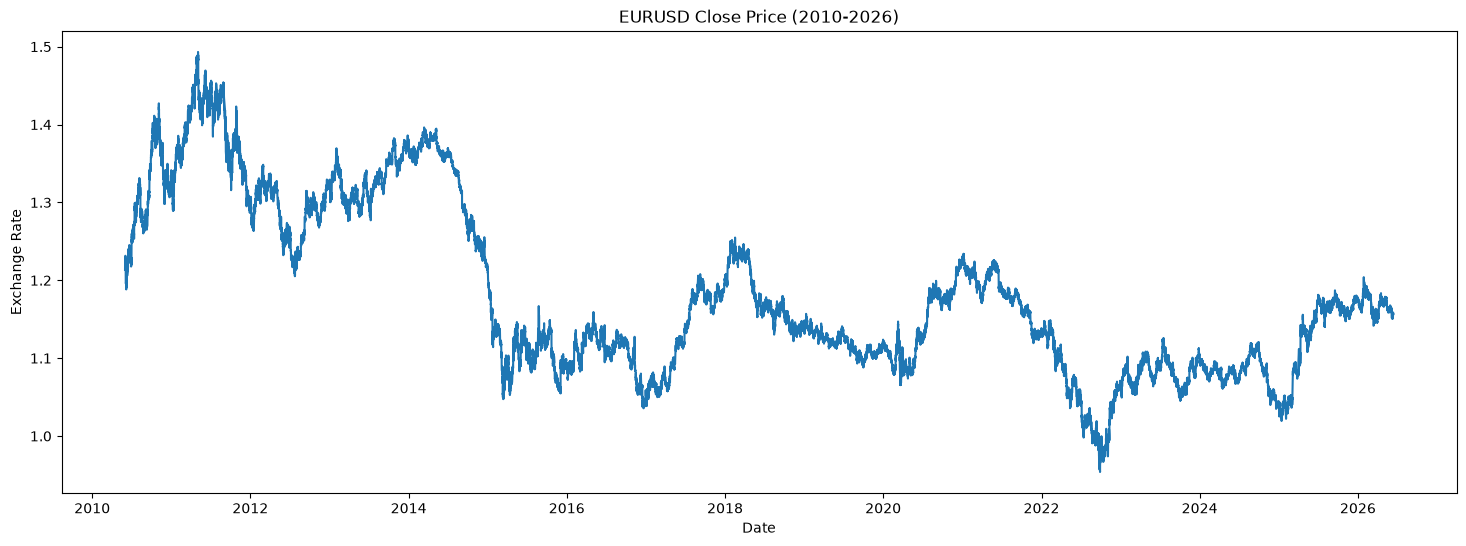

In [65]:
plt.figure(figsize=(18,6))

plt.plot(df.index, df["close"])

plt.title("EURUSD Close Price (2010-2026)")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.show()

## Recent Years

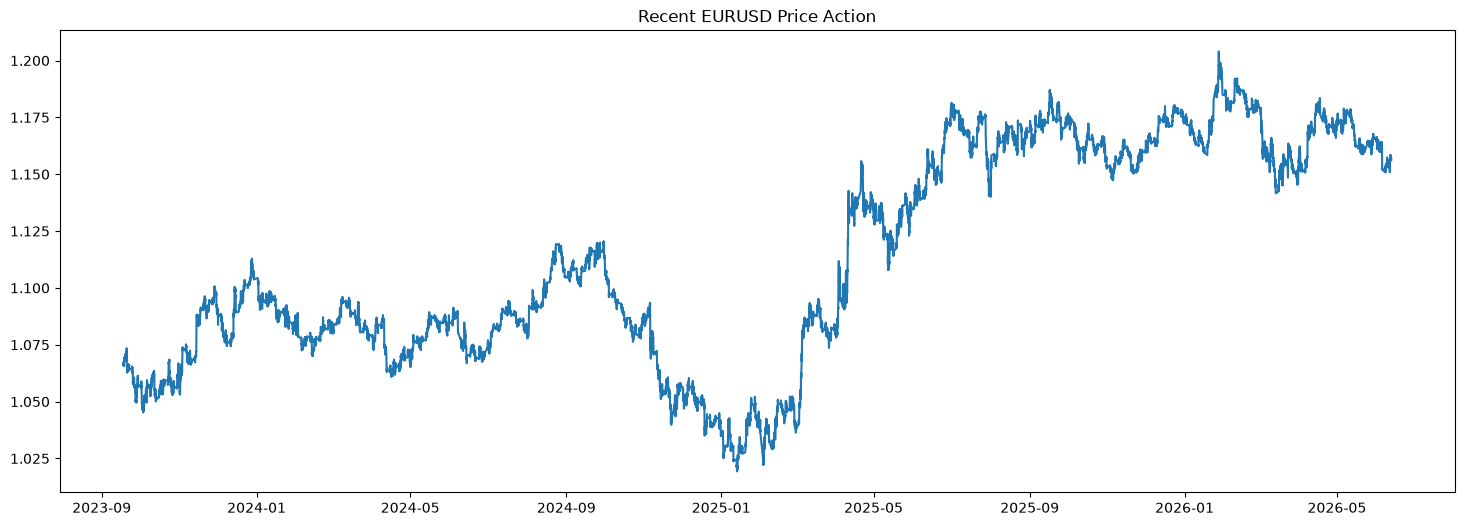

In [67]:
recent = df.loc[df.index >= (df.index.max() - pd.Timedelta(days=1000))]

plt.figure(figsize=(18,6))
plt.plot(recent.index, recent["close"])
plt.title("Recent EURUSD Price Action")
plt.show()

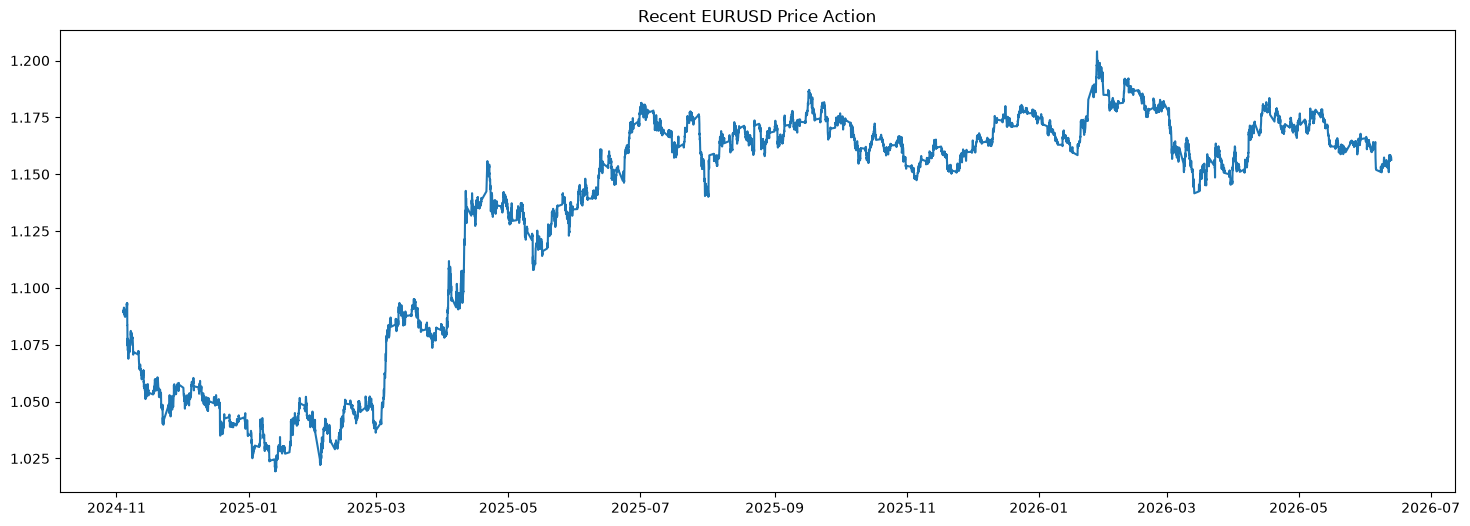

In [68]:
recent = df.tail(10000)

plt.figure(figsize=(18,6))
plt.plot(recent.index, recent["close"])
plt.title("Recent EURUSD Price Action")
plt.show()

## Distribution Analysis

In [71]:
df.head()

,open,high,low,close,volume
datetime,,,,,
2010-06-01 10:00:00,1.21266,1.21436,1.21185,1.21357,3720
2010-06-01 11:00:00,1.21346,1.21768,1.21325,1.21614,3269
2010-06-01 12:00:00,1.21623,1.21830,1.21499,1.21775,3512
2010-06-01 13:00:00,1.21781,1.22279,1.21737,1.22167,4899
2010-06-01 14:00:00,1.22166,1.23521,1.22118,1.22866,5019


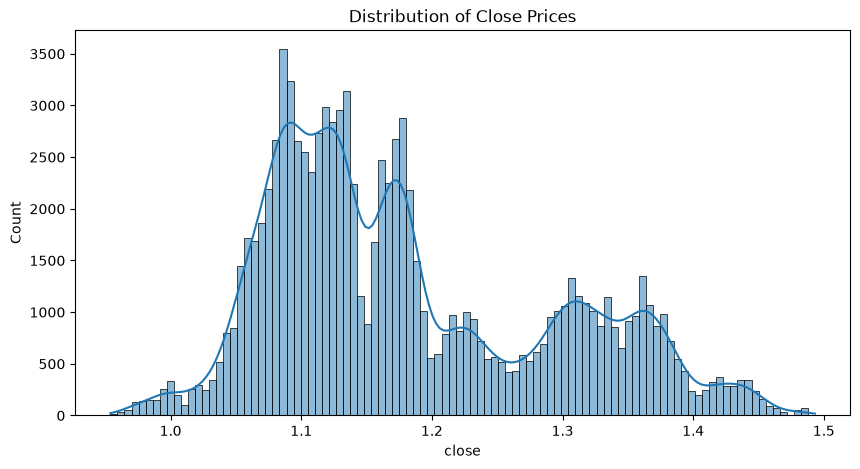

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["close"], # type: ignore
    bins=100,
    kde=True
)

plt.title("Distribution of Close Prices")
plt.show()

## return analysis

In [73]:
df["returns"] = df["close"].pct_change()

In [74]:
df["returns"].describe()

count    9.999900e+04
mean     9.237750e-08
std      1.072228e-03
min     -2.039421e-02
25%     -4.313180e-04
50%      0.000000e+00
75%      4.310772e-04
max      1.740861e-02
Name: returns, dtype: float64

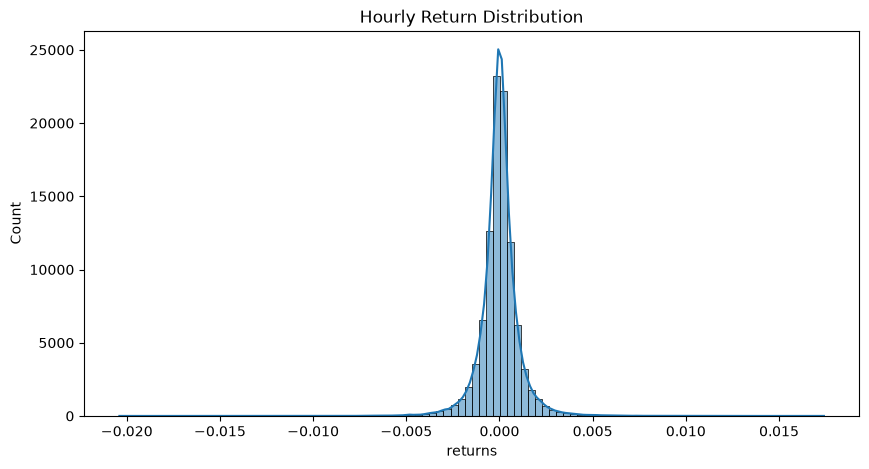

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["returns"].dropna(), # type: ignore
    bins=100,
    kde=True
)

plt.title("Hourly Return Distribution")

plt.show()

### Volatality Analysis - 24 HOurs

In [76]:
df["volatility"] = (
    df["returns"]
    .rolling(24)
    .std()
)

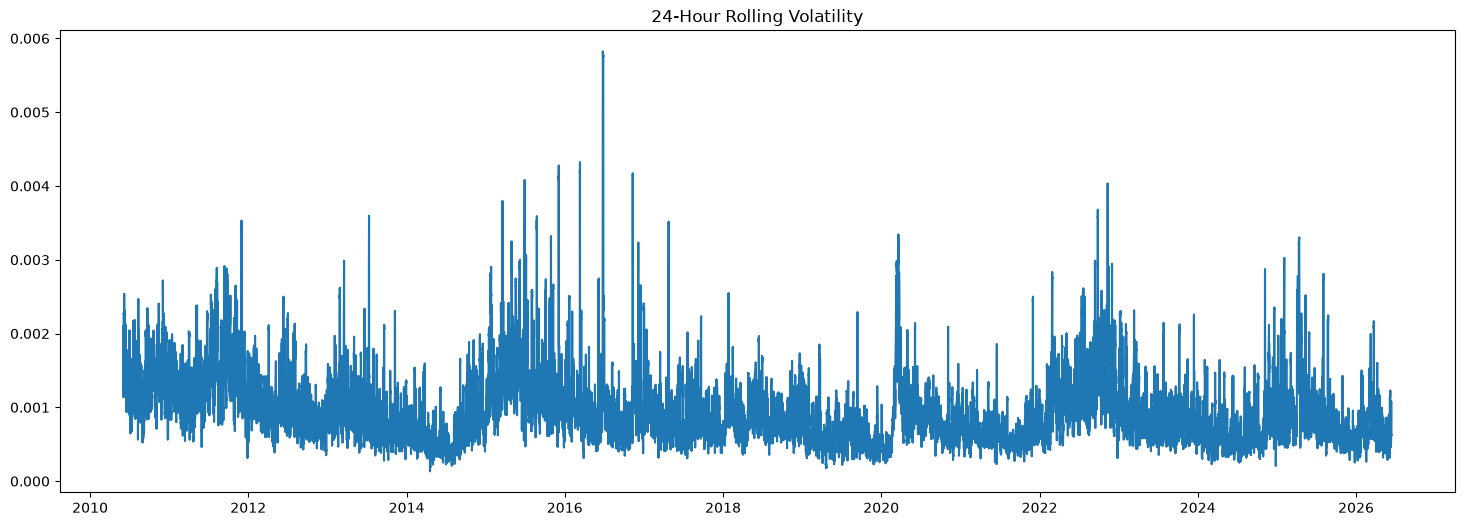

In [77]:
plt.figure(figsize=(18,6))

plt.plot(
    df.index,
    df["volatility"]
)

plt.title("24-Hour Rolling Volatility")

plt.show()

### Correlation

In [78]:
corr = df[
    ["open","high","low","close"]
].corr()

corr


,open,high,low,close
open,1.000000,0.999958,0.999960,0.999932
high,0.999958,1.000000,0.999928,0.999963
low,0.999960,0.999928,1.000000,0.999963
close,0.999932,0.999963,0.999963,1.000000


<Axes: >

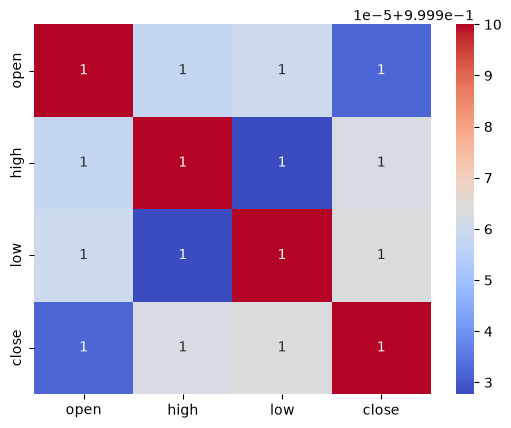

In [79]:
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

### Volume Analysis

In [80]:
df["volume"].describe()

count    100000.000000
mean      10015.656640
std       10564.672101
min           1.000000
25%        3815.000000
50%        7212.000000
75%       12703.250000
max      688880.000000
Name: volume, dtype: float64

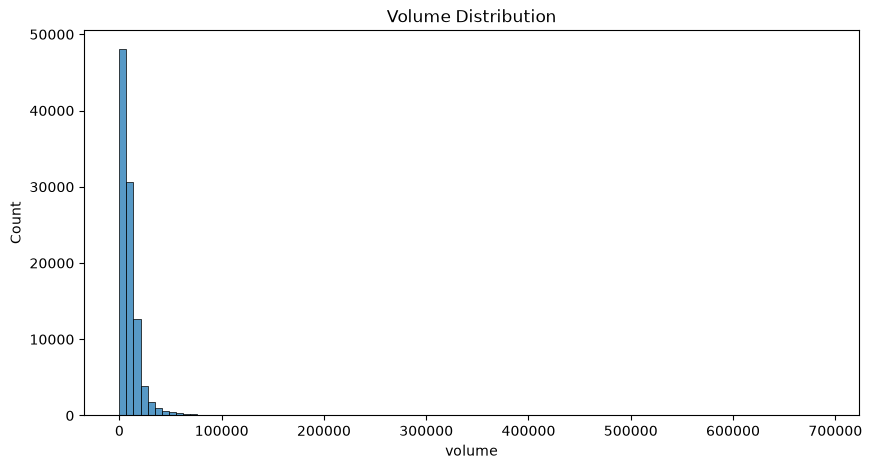

In [81]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["volume"],
    bins=100
)

plt.title("Volume Distribution")

plt.show()

### Average Hourly Volume - Time-Based Analysis


In [82]:
hourly_volume = (
    df.groupby(df.index.hour)
      ["volume"]
      .mean()
)

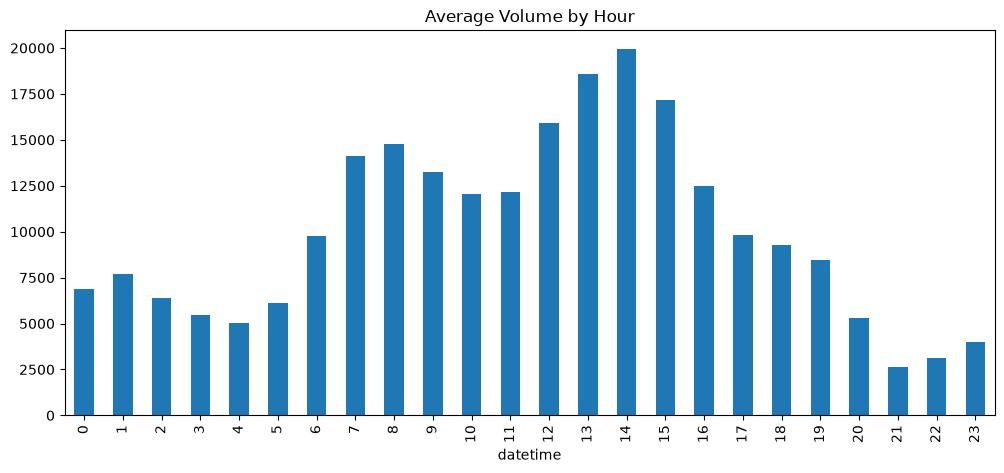

In [83]:
hourly_volume.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Average Volume by Hour")
plt.show()